# Random Forest Binary Classification

This notebook implements a complete machine learning pipeline for binary classification of coronary artery stenosis using Random Forest.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data, create binary target
3. **Dropping dependent Features**: Remove derived variables
4. **Preprocessing**: Clean data, handle missing values, and prepare features
5. **Build Pipeline**: Train Random Forest classifier with SMOTE and feature selection
6. **Evaluation**: Comprehensive evaluation metrics
7. **Overfitting Check**: Compare training vs. test performance
8. **Visualization**: ROC and Precision-Recall curves
9. **Feature Importance**: Identify most important features
10. **Gridsearch** (Optional): Hyperparameter optimization
11. **Feature Selection Optimization** (Optional): Find optimal number of features


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **sklearn.ensemble**: Random Forest classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization
- **scipy.stats**: Statistical distributions for randomized search


In [87]:
import pandas as pd
import numpy as np
from scipy.stats import uniform, randint

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    f1_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt



## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Removes features with more than 62.5% missing values
- Removes class 1 (non-significant stenosis) to create binary classification
- Automatically converts object columns that look numeric to appropriate data types
- Displays cleaned dataset shape


In [88]:
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)

threshold = 0.625
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(f"Converted {len(numeric_like_cols)} mostly-numeric columns")
print(f"Cleaned dataset shape: {data.shape}")



Converted 6 mostly-numeric columns
Cleaned dataset shape: (1678, 94)


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_81222/2064431094.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


## 3. Dropping dependent Features

This cell removes dependent variables that are directly derived from other features. These features contain redundant information and can cause multicollinearity issues.


In [89]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)



## 4. Preprocessing

This cell performs comprehensive data preprocessing:

**Feature Type Identification:**
- Identifies categorical and numerical features
- Automatically converts object columns that look numeric
- Handles manual categorical feature definitions

**Data Cleaning:**
- Removes highly correlated features (correlation > 0.95) to reduce redundancy
- Creates binary target: 0 = No Stenosis, 1 = Significant Stenosis

**Train/Test Split:**
- Splits data into 80% training and 20% test set
- Uses stratified split to maintain class distribution

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: Median imputation


In [90]:
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)

if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )

numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_pre = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)

preprocessor.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

from scipy.sparse import issparse
if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nTransformed shapes:")
print(f"  Training: {X_train_transformed.shape}")
print(f"  Test: {X_test_transformed.shape}")



Forced 48 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features: 7
Numerical features: 79
Removing 1 highly correlated features
After cleaning - Numerical: 78, Categorical: 7

Transformed shapes:
  Training: (1342, 96)
  Test: (336, 96)


## 5. Build Pipeline

This cell builds and trains the Random Forest model with the complete pipeline:

**Process:**
1. Fits preprocessor on training data and transforms both sets
2. Performs feature selection (SelectKBest with mutual information, k=55)
3. Builds pipeline with SMOTE (oversampling) and Random Forest classifier
4. Performs 5-fold cross-validation to assess model performance
5. Trains final model on full training set
6. Makes predictions on test set

**Hyperparameters:**
- Optimized for high recall of Significant Stenosis (class 1)
- Uses class_weight='balanced' to handle class imbalance
- Regularization through max_depth and min_samples_split


In [91]:
np.random.seed(42)

K_FEATURES = 55
SMOTE_K_NEIGHBORS = 3

class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution:")
for cls, count in class_counts.items():
    class_name = {0: "No Stenosis", 1: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nMethods:")
print(f"  1. Median Imputation")
print(f"  2. 80:20 Train/Test Split")
print(f"  3. SMOTE Oversampling (k_neighbors={SMOTE_K_NEIGHBORS})")
print(f"  4. Feature Selection (k={K_FEATURES})")
print(f"  5. Random Forest with class_weight='balanced'")
print(f"\nUsing GridSearch Optimized Parameters:")
print(f"  Best CV Score from GridSearch: 0.8116")
print(f"  GridSearch used custom scorer: 0.65 * Recall + 0.35 * Balanced Accuracy")
print(f"  K_FEATURES={K_FEATURES}")
print(f"  n_estimators=134")
print(f"  max_depth=18")
print(f"  min_samples_split=3")
print(f"  min_samples_leaf=3")
print(f"  max_features='log2'")

pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=K_FEATURES)),
    ("smote", SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')),
    ("classifier", RandomForestClassifier(
        n_estimators=134,
        max_depth=18,
        min_samples_split=3,
        min_samples_leaf=3,
        max_features='log2',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print(f"\nTraining model...")
pipeline.fit(X_train_transformed, y_train)

feature_selector = pipeline.named_steps['feature_selection']
selected_features_mask = feature_selector.get_support()
X_train_selected = X_train_transformed[:, selected_features_mask]
X_test_selected = X_test_transformed[:, selected_features_mask]

print(f"\nFeature Selection:")
print(f"   Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_transformed, y_train, cv=cv_strategy, scoring='balanced_accuracy')
print(f"\nCross-Validation Results:")
print(f"   Mean Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = pipeline.predict(X_test_transformed)
y_proba = pipeline.predict_proba(X_test_transformed)

print(f"\nModel training completed!")



Class distribution:
  No Stenosis (Class 0): 290 samples (21.6%)
  Significant Stenosis (Class 1): 1052 samples (78.4%)

Methods:
  1. Median Imputation
  2. 80:20 Train/Test Split
  3. SMOTE Oversampling (k_neighbors=3)
  4. Feature Selection (k=55)
  5. Random Forest with class_weight='balanced'

Using GridSearch Optimized Parameters:
  Best CV Score from GridSearch: 0.8116
  GridSearch used custom scorer: 0.65 * Recall + 0.35 * Balanced Accuracy
  K_FEATURES=55
  n_estimators=134
  max_depth=18
  min_samples_split=3
  min_samples_leaf=3
  max_features='log2'

Training model...

Feature Selection:
   Selected 55 features out of 96

Cross-Validation Results:
   Mean Balanced Accuracy: 0.6644 (+/- 0.0952)

Model training completed!


## 6. Evaluation

This cell performs comprehensive model evaluation:
- Calculates classification metrics (accuracy, balanced accuracy, precision, recall, F1)
- Generates confusion matrix
- Provides per-class performance metrics
- Evaluates model performance on the test set


MODEL EVALUATION

Overall Accuracy: 0.7946
Balanced Accuracy: 0.7055
F1 Score: 0.8681
Mean CV Balanced Accuracy: 0.6644

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.53      0.55      0.54        73
Significant Stenosis       0.87      0.86      0.87       263

            accuracy                           0.79       336
           macro avg       0.70      0.71      0.70       336
        weighted avg       0.80      0.79      0.80       336


Confusion Matrix:


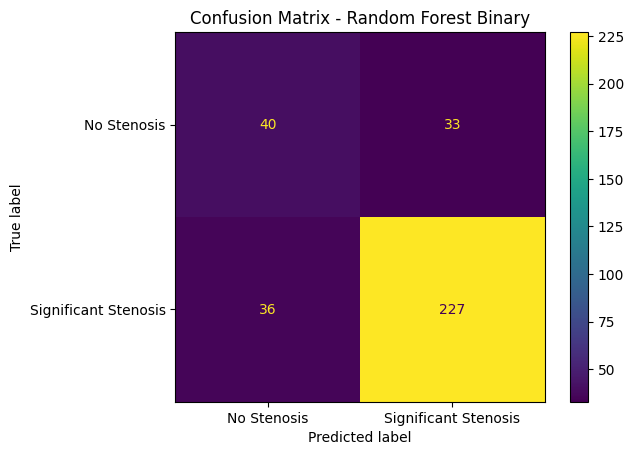


Per-Class Recall:
  No Stenosis (Class 0): 0.5479
  Significant Stenosis (Class 1): 0.8631


In [92]:
print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Mean CV Balanced Accuracy: {cv_scores.mean():.4f}")

print("\n" + "=" * 80)
print("Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"]))

print("\n" + "=" * 80)
print("Confusion Matrix:")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Stenosis", "Significant Stenosis"]).plot()
plt.title("Confusion Matrix - Random Forest Binary")
plt.show()

recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]

print(f"\nPer-Class Recall:")
print(f"  No Stenosis (Class 0): {recall_class0:.4f}")
print(f"  Significant Stenosis (Class 1): {recall_class1:.4f}")



## 7. Overfitting Check

This cell compares training and test set performance to detect overfitting:
- Calculates metrics on both training and test sets
- Compares balanced accuracy, recall, and overall accuracy
- Identifies performance gaps that indicate overfitting
- Helps validate model generalization


In [ ]:
y_pred_train = pipeline.predict(X_train_transformed)

train_recall_class1 = recall_score(y_train, y_pred_train, labels=[1], average=None)[0]
test_recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\n Recall (Significant Stenosis - Class 1)")
print(f"  Training: {train_recall_class1:.4f}")
print(f"  Test:     {test_recall_class1:.4f}")
print(f"  Gap:      {train_recall_class1 - test_recall_class1:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("  WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("  CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")
    print(f"  Recall gap (Class 1): {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")



OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)

 Recall (Significant Stenosis - Class 1)
  Training: 0.9905
  Test:     0.8479
  Gap:      0.1426

Balanced Accuracy:
  Training: 0.9763
  Test:     0.7253
  Gap:      0.2510

Regular Accuracy:
  Training: 0.9844
  Test:     0.7946
  Gap:      0.1897

   Consider: stronger regularization, fewer features, or simpler model


## 8. Visualization: ROC and Precision-Recall Curves

This cell visualizes model performance with binary ROC and Precision-Recall curves:
- Plots ROC curve showing True Positive Rate vs. False Positive Rate
- Plots Precision-Recall curve showing Precision vs. Recall
- Shows AUC and Average Precision metrics
- Provides visual assessment of model performance


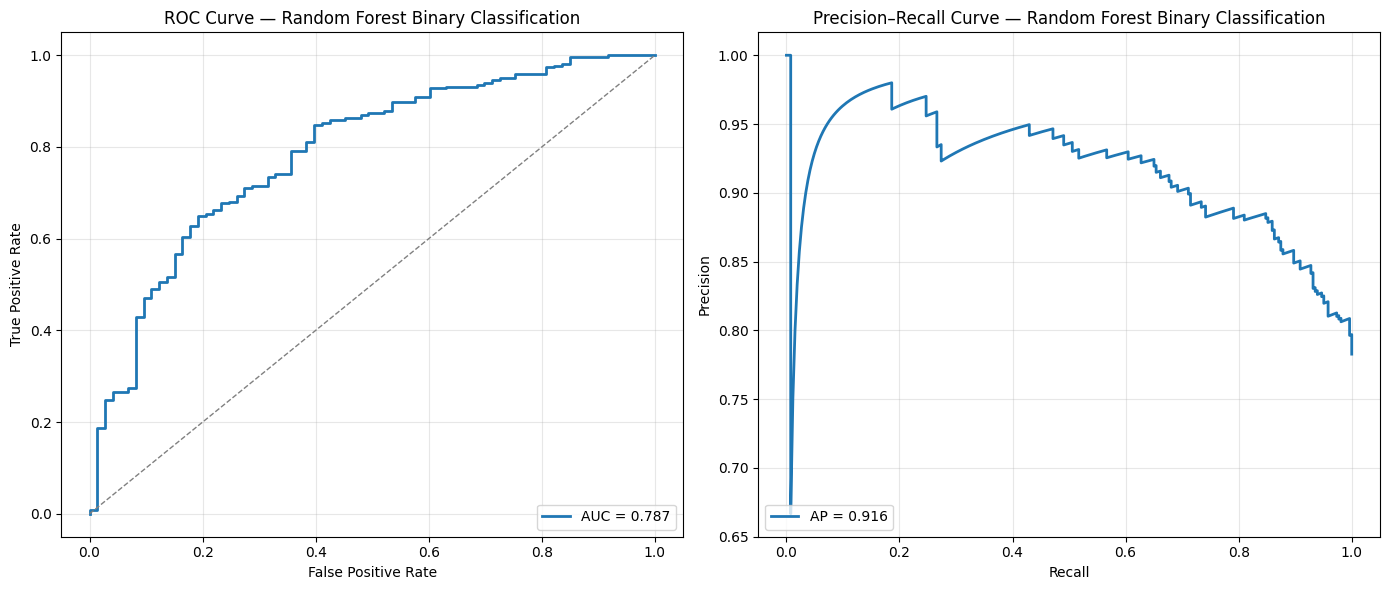


ROC AUC: 0.7867
Average Precision: 0.9163


In [79]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1])
avg_precision = average_precision_score(y_test, y_proba[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest Binary Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(recall, precision, lw=2, label=f'AP = {avg_precision:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Random Forest Binary Classification')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")



## 9. Feature Importance

This cell identifies and visualizes the most important features:
- Extracts feature importance from the trained Random Forest model
- Maps feature names to selected features
- Plots top 15 most important features
- Helps understand which features drive model predictions


Top 15 Most Important Features:
               Feature  Importance
     cat__geschlecht_1    0.100962
     cat__geschlecht_0    0.089814
          num__Alter_0    0.078702
      num__Fibrinogen0    0.036728
           num__Kreat0    0.032656
           num__hba1c0    0.031441
            num__LDL_0    0.028490
        num__Glucose_0    0.027620
        num__cholest_0    0.025976
  num__apo_A1_gesamt_0    0.025790
              num__TnI    0.025738
           num__leuko0    0.023265
num__Delta_Blutglucose    0.021822
        num__triglyc_0    0.021437
            num__WHR_0    0.021173


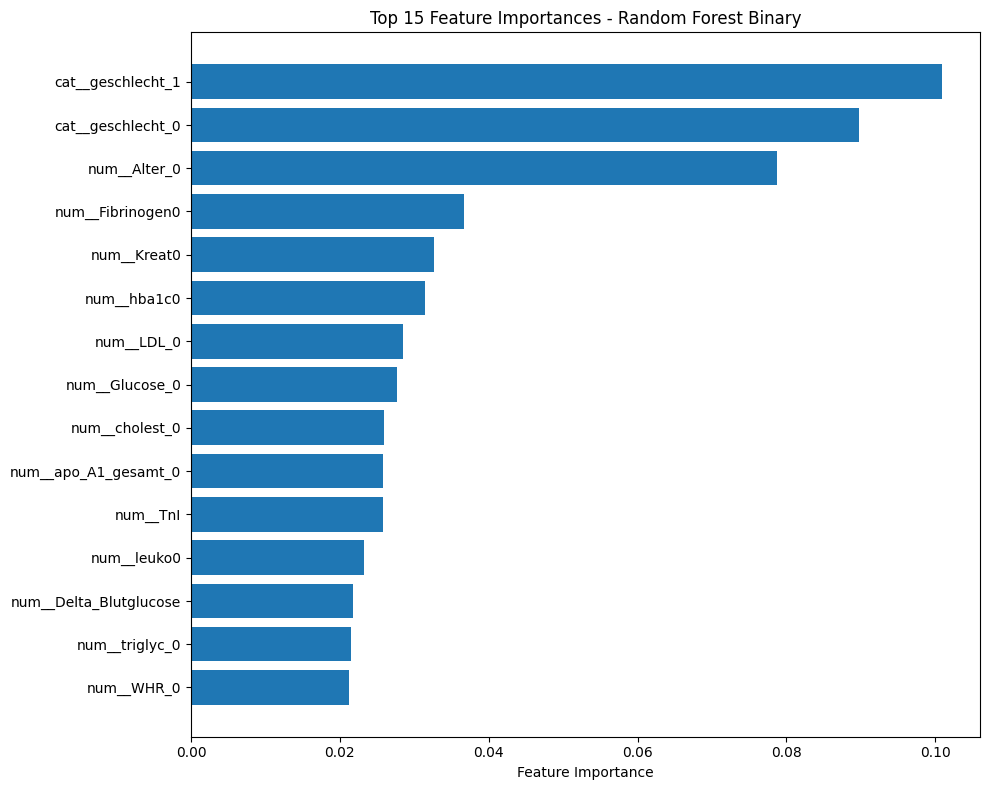

In [80]:
feature_importances = pipeline.named_steps['classifier'].feature_importances_
selected_feature_names = preprocessor.get_feature_names_out()[selected_features_mask]

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest Binary')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



## 10. Gridsearch (Optional)

This cell performs hyperparameter optimization using RandomizedSearchCV:
- Searches over a distribution of hyperparameters
- Uses cross-validation to evaluate parameter combinations
- Finds optimal hyperparameters for the Random Forest classifier
- Can be skipped if using default parameters from the pipeline cell

**Note:** Randomized Search is more efficient than Grid Search for large parameter spaces.


In [ ]:
use_randomized_search = True

if use_randomized_search:
    def combined_recall_balanced_scorer(y_true, y_pred):
        recall_class1 = recall_score(y_true, y_pred, labels=[1], average=None)[0]
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        return 0.65 * recall_class1 + 0.35 * bal_acc

    custom_scorer = make_scorer(combined_recall_balanced_scorer)

    param_distributions = {
        'classifier__n_estimators': randint(100, 600),
        'classifier__max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20, 25, None],
        'classifier__min_samples_split': [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30],
        'classifier__min_samples_leaf': [1, 2, 3, 4, 5, 6, 8, 10, 12],
        'classifier__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=200,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=custom_scorer,
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    print("Starting Randomized Search...")
    random_search.fit(X_train_transformed, y_train)

    print(f"\nBest parameters: {random_search.best_params_}")
    print(f"Best CV score: {random_search.best_score_:.4f}")

    best_pipeline = random_search.best_estimator_
    y_pred = best_pipeline.predict(X_test_transformed)
    y_proba = best_pipeline.predict_proba(X_test_transformed)
else:
    print("Randomized Search skipped. Using default parameters.")



Starting Randomized Search...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


[CV] END classifier__max_depth=10, classifier__max_features=0.3, classifier__min_samples_leaf=10, classifier__min_samples_split=6, classifier__n_estimators=202; total time=   1.8s
[CV] END classifier__max_depth=10, classifier__max_features=0.3, classifier__min_samples_leaf=10, classifier__min_samples_split=6, classifier__n_estimators=202; total time=   1.8s
[CV] END classifier__max_depth=10, classifier__max_features=0.3, classifier__min_samples_leaf=10, classifier__min_samples_split=6, classifier__n_estimators=202; total time=   1.8s
[CV] END classifier__max_depth=10, classifier__max_features=0.3, classifier__min_samples_leaf=10, classifier__min_samples_split=6, classifier__n_estimators=202; total time=   1.9s
[CV] END classifier__max_depth=10, classifier__max_features=0.3, classifier__min_samples_leaf=10, classifier__min_samples_split=6, classifier__n_estimators=202; total time=   1.9s
[CV] END classifier__max_depth=18, classifier__max_features=0.2, classifier__min_samples_leaf=8, cla

## 11. Feature Selection Optimization (Optional)

This cell tests different numbers of features (k values) to find the optimal feature count that balances model complexity and performance.

**Process:**
- Tests k values from 30 to 80 features with steps of 5 (30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80)
- For each k, performs quick 3-fold cross-validation with a simplified model
- Compares balanced accuracy scores across different k values
- Visualizes results to identify the optimal number of features
- Provides recommendation for best k value

**Note:** This is an optimization step that can help improve model performance by finding the right balance between feature count and model complexity. Smaller steps (5 instead of 10) provide more granular optimization.


Testing different feature selection k values...
k=30: CV Balanced Accuracy = 0.6725 (+/- 0.0537)
k=35: CV Balanced Accuracy = 0.6692 (+/- 0.0773)
k=40: CV Balanced Accuracy = 0.6756 (+/- 0.0521)
k=45: CV Balanced Accuracy = 0.6743 (+/- 0.0177)
k=50: CV Balanced Accuracy = 0.6695 (+/- 0.0708)
k=55: CV Balanced Accuracy = 0.6906 (+/- 0.0710)
k=60: CV Balanced Accuracy = 0.6845 (+/- 0.0109)
k=65: CV Balanced Accuracy = 0.6696 (+/- 0.0512)
k=70: CV Balanced Accuracy = 0.6822 (+/- 0.0626)
k=75: CV Balanced Accuracy = 0.6683 (+/- 0.0459)
k=80: CV Balanced Accuracy = 0.6629 (+/- 0.0236)

Best k: 55 features (CV Balanced Accuracy: 0.6906)

Recommendation: Consider using k=55 instead of k=50 if performance is better


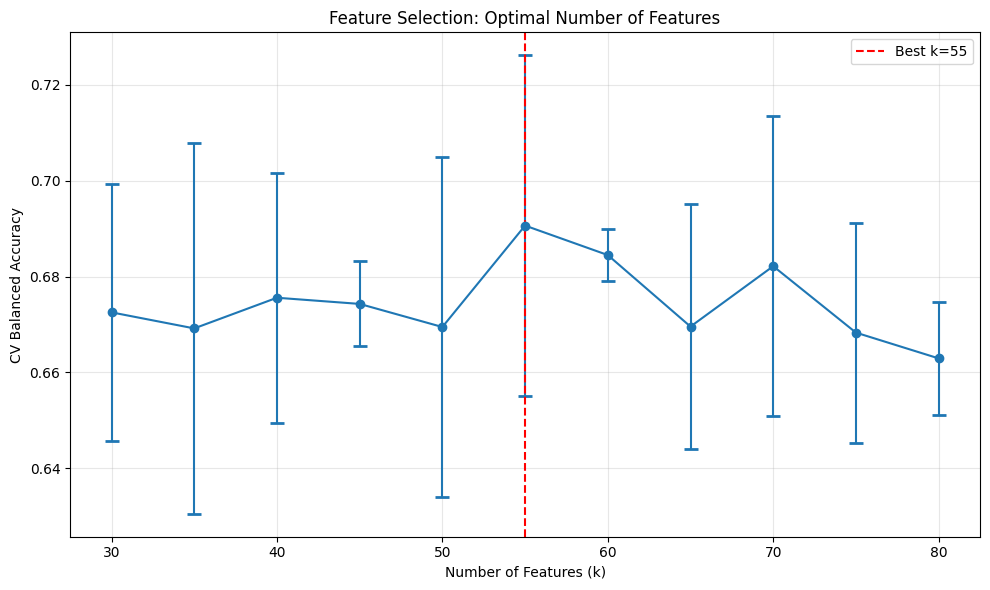

In [ ]:
optimize_features = True

if optimize_features:
    k_values = [30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
    results = []

    print("Testing different feature selection k values...")
    print("=" * 60)

    for k in k_values:
        selector_k = SelectKBest(mutual_info_classif, k=k)
        X_train_k = selector_k.fit_transform(X_train_transformed, y_train)
        X_test_k = selector_k.transform(X_test_transformed)
        
        temp_pipeline = Pipeline([
            ("smote", SMOTE(random_state=42, k_neighbors=3)),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                max_depth=8,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )),
        ])
        
        cv_strategy_k = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        cv_scores_k = cross_val_score(temp_pipeline, X_train_k, y_train, cv=cv_strategy_k, scoring='balanced_accuracy')
        
        results.append({
            'k': k,
            'cv_mean': cv_scores_k.mean(),
            'cv_std': cv_scores_k.std()
        })
        
        print(f"k={k:2d}: CV Balanced Accuracy = {cv_scores_k.mean():.4f} (+/- {cv_scores_k.std()*2:.4f})")

    results_df = pd.DataFrame(results)
    best_k = results_df.loc[results_df['cv_mean'].idxmax(), 'k']
    best_score = results_df.loc[results_df['cv_mean'].idxmax(), 'cv_mean']

    print("\n" + "=" * 60)
    print(f"Best k: {best_k} features (CV Balanced Accuracy: {best_score:.4f})")
    print(f"\nRecommendation: Consider using k={best_k} instead of k=50 if performance is better")

    plt.figure(figsize=(10, 6))
    plt.errorbar(results_df['k'], results_df['cv_mean'], 
                 yerr=results_df['cv_std'], 
                 marker='o', capsize=5, capthick=2)
    plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
    plt.xlabel('Number of Features (k)')
    plt.ylabel('CV Balanced Accuracy')
    plt.title('Feature Selection: Optimal Number of Features')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Feature Selection Optimization skipped.")

